# 👩‍💻 Build Perceptron for Binary Classification

## 📋 Overview
In this lab, you will implement a perceptron model from scratch for binary classification using PyTorch tensors. You'll generate synthetic data, train your model using the perceptron learning rule, visualize the decision boundary, and experiment with different learning rates. By building this fundamental neural network component yourself, you'll gain deeper insights into how neural networks learn and make predictions.


- Implement a perceptron model from scratch using PyTorch tensors
- Apply the perceptron learning rule to train a binary classifier
- Visualize decision boundaries and observe their evolution during training
- Analyze how different learning rates affect model convergence and performance

## Task 1: Dataset Setup
**Context:** Before building a classifier, you first need data. In real-world scenarios, data scientists often start with exploratory data analysis and visualization to understand the classification problem better.

**Steps:**

1. Import the necessary libraries
    - Use PyTorch (`torch`) for tensor operations
    - Use Scikit-learn's `make_classification` to generate synthetic data
    - Import matplotlib for visualization

In [1]:
# Import necessary libraries

import torch
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

2. Generate a synthetic binary classification dataset
    - Create 200 samples with 2 features using `make_classification`
    - Set `n_clusters_per_class=1` and `class_sep=2` to ensure good separation
    - Convert the NumPy arrays to PyTorch tensors

In [2]:
# Generate synthetic dataset and convert to PyTorch tensors

# Generate datset 

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

# Convert to PyTorch tensors

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

3. Visualize the dataset
    - Create a scatter plot showing the two classes in different colors
    - Add a legend and appropriate labels to the axes

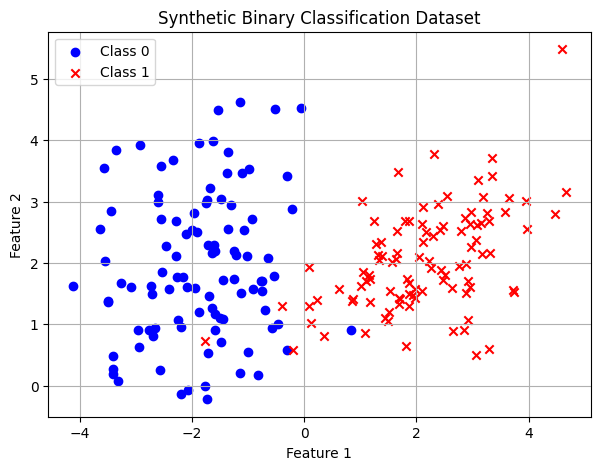

In [5]:
# Visualize dataset with different colors for each class

plt.figure(figsize=(7, 5))

# Plot class 0
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color='blue',
    marker='o',
    label='Class 0'
)

# Plot class 1
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color='red',
    marker='x',
    label='Class 1'
)

plt.title("Synthetic Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Task 2: Implementing the Perceptron
**Context:** In industry, understanding how models work "under the hood" is crucial for effective debugging and customization. Building a perceptron from scratch helps cement your understanding of the fundamental building block of neural networks.

**Steps:**

1. Create a Perceptron class
    - Initialize weights and bias as PyTorch tensors
    - Include parameters for input dimension and learning rate

2. Implement the forward pass method
    - Calculate the weighted sum of inputs
    - Apply an activation function (e.g., sigmoid) to the sum
    - Return the prediction
    
3. Implement a method to update weights manually
    - Accept inputs and corresponding target values
    - Calculate prediction error
    - Update weights according to the perceptron learning rule

In [7]:
# Define Perceptron class with appropriate initialization

import torch.nn as nn
import torch.nn.functional as F

class Perceptron:
    def __init__(self, input_dim, learning_rate=0.01):
        # Initialise weights and bias
        
        self.weights = torch.randn(input_dim, dtype=torch.float32)
        
        self.bias = torch.randn(1, dtype=torch.float32)
        
        self.lr = learning_rate
    
    # Implement forward method for making predictions
    
    def forward(self, x):
        """
        x: tensor of shape [input_dim]
        returns: prediction between 0 and 1
        """
        z = torch.dot(self.weights, x) + self.bias
        y_hat = torch.sigmoid(z) # activation 
        
        return y_hat
    
    # Implement weight update method based on perceptron learning rule
    
    def update(self, x, target):
        """
        x: tensort of shape[input_dim]
        target: scalar (0 to 1)
        """
        prediction =self.forward(x)
        error = target - prediction
        
        # Perceptron learning rule
        
        self.weights += self.lr * error * x
        self.bias += self.lr * error

In [11]:
# Initialise perceptron 
p = Perceptron(input_dim=2, learning_rate=0.1)

print("Initial weights:", p.weights)
print("Initial bias:", p.bias)

# Test forward pass

sample_x = torch.tensor([0.5, -1.2], dtype=torch.float32)
pred = p.forward(sample_x)

print("Prediction:", pred.item())

# Test weight update

target = torch.tensor(1.0)

print("Before update:", p.weights)

p.update(sample_x, target)

print("After update:", p.weights)

Initial weights: tensor([ 0.4070, -0.0238])
Initial bias: tensor([0.4861])
Prediction: 0.6722021102905273
Before update: tensor([ 0.4070, -0.0238])
After update: tensor([ 0.4234, -0.0631])


## Task 3: Training the Perceptron
**Context:** Training neural networks is an iterative process where the model learns from examples over multiple passes through the dataset (epochs). Monitoring this process helps ensure the model is learning effectively.

**Steps:**

1. Implement the training loop
    - Loop through a specified number of epochs
    - For each epoch, iterate through all training examples
    - Call your weight update method for each example
    - Track metrics like accuracy or loss after each epoch

In [18]:
# Implement training loop with epoch iterations

def train(model, X, y, epochs=20):
    for epoch in range(epochs):
        
        # Shuffle indicies
        
        indices = torch.randperm(len(X))
        
        for i in indices:
            model.update(X[i], y[i])
            
        # Track accuracy 
        
        acc = compute_accuracy(model, X, y)
        
        print(f"Epoch {epoch+1}/{epochs}  |  Accuracy: {acc:.2f}%")

2. Create a function to calculate accuracy
    - Convert continuous predictions to binary classes
    - Compare predictions with true labels
    - Calculate and return the accuracy percentage

In [21]:
# Implement function to calculate classification accuracy

def compute_accuracy(model, X, y):
    correct = 0
    
    for i in range(len(X)):
        pred = model.forward(X[i])
        pred_class = 1 if pred >= 0.5 else 0
        
        if pred_class == int(y[i].item()):
            correct += 1
    
    accuracy = 100 * correct / len(X)
    return accuracy

3. Train your perceptron
    - Initialize your model with appropriate parameters
    - Call the training function with your dataset
    - Print progress updates during training

In [22]:
# Train the model and track progress

p = Perceptron(input_dim=2, learning_rate=0.1)
train(p, X_tensor, y_tensor, epochs=20)

Epoch 1/20  |  Accuracy: 96.50%
Epoch 2/20  |  Accuracy: 97.50%
Epoch 3/20  |  Accuracy: 98.00%
Epoch 4/20  |  Accuracy: 98.00%
Epoch 5/20  |  Accuracy: 98.00%
Epoch 6/20  |  Accuracy: 98.00%
Epoch 7/20  |  Accuracy: 98.00%
Epoch 8/20  |  Accuracy: 98.50%
Epoch 9/20  |  Accuracy: 98.50%
Epoch 10/20  |  Accuracy: 98.50%
Epoch 11/20  |  Accuracy: 98.50%
Epoch 12/20  |  Accuracy: 98.50%
Epoch 13/20  |  Accuracy: 98.50%
Epoch 14/20  |  Accuracy: 98.50%
Epoch 15/20  |  Accuracy: 98.50%
Epoch 16/20  |  Accuracy: 98.00%
Epoch 17/20  |  Accuracy: 98.50%
Epoch 18/20  |  Accuracy: 98.50%
Epoch 19/20  |  Accuracy: 98.50%
Epoch 20/20  |  Accuracy: 98.50%


In [23]:
print("Weights:", p.weights)
print("Bias:", p.bias)

Weights: tensor([ 3.2036, -0.7042])
Bias: tensor([1.3470])


## Task 4: Decision Boundary Visualization
**Context:** Visualizing machine learning models helps communicate results to stakeholders and provides insights into how the model makes decisions. For binary classifiers, the decision boundary is particularly informative.

**Steps:**

1. Create a function to plot the decision boundary
    - Generate a mesh grid covering the feature space
    - Make predictions for each point in the grid
    - Use `contourf()` or similar to plot the decision regions
    - Overlay the original data points

In [24]:
# Implement function to visualize decision boundary

import numpy as np


def plot_decision_boundary(model, X, y, resolution=0.02):
    # Extract feature ranges
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create mesh grid
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )

    # Flatten grid and convert to tensor
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

    # Predict for each point
    preds = []
    for point in grid_tensor:
        pred = model.forward(point)
        preds.append(1 if pred >= 0.5 else 0)

    Z = np.array(preds).reshape(xx.shape)

    # Plot decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Overlay original data
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Class 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class 1')

    plt.title("Decision Boundary of Perceptron")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

2. Visualize the trained model's decision boundary
    - Call your plotting function with the trained perceptron
    - Add appropriate labels and a title to the plot

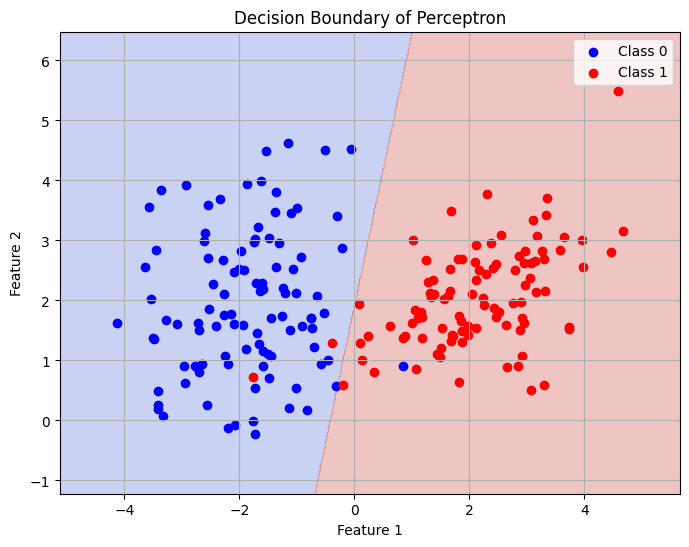

In [25]:
# Call visualization function with trained model
plot_decision_boundary(p, X, y)

3. Implement a function to visualize weights during training
    - Store weights at specific intervals during training
    - Plot how the weight values change over time

In [26]:
# Implement function to track and visualize weight evolution

# Modify training loop to record weights

def train_with_tracking(model, X, y, epochs=20):
    weight_history = []

    for epoch in range(epochs):
        indices = torch.randperm(len(X))

        for i in indices:
            model.update(X[i], y[i])

        # Store weight snapshot
        weight_history.append(model.weights.clone().numpy())

        acc = compute_accuracy(model, X, y)
        print(f"Epoch {epoch+1}/{epochs} | Accuracy: {acc:.2f}%")

    return np.array(weight_history)

In [27]:
# Plot weight evolution

def plot_weight_evolution(weight_history):
    plt.figure(figsize=(8, 5))

    plt.plot(weight_history[:, 0], label='Weight w1')
    plt.plot(weight_history[:, 1], label='Weight w2')

    plt.title("Weight Evolution During Training")
    plt.xlabel("Epoch")
    plt.ylabel("Weight Value")
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch 1/20 | Accuracy: 96.00%
Epoch 2/20 | Accuracy: 98.00%
Epoch 3/20 | Accuracy: 98.00%
Epoch 4/20 | Accuracy: 97.50%
Epoch 5/20 | Accuracy: 98.00%
Epoch 6/20 | Accuracy: 98.00%
Epoch 7/20 | Accuracy: 98.00%
Epoch 8/20 | Accuracy: 97.50%
Epoch 9/20 | Accuracy: 98.50%
Epoch 10/20 | Accuracy: 98.50%
Epoch 11/20 | Accuracy: 98.50%
Epoch 12/20 | Accuracy: 98.50%
Epoch 13/20 | Accuracy: 98.50%
Epoch 14/20 | Accuracy: 98.50%
Epoch 15/20 | Accuracy: 98.50%
Epoch 16/20 | Accuracy: 98.50%
Epoch 17/20 | Accuracy: 98.50%
Epoch 18/20 | Accuracy: 98.50%
Epoch 19/20 | Accuracy: 98.50%
Epoch 20/20 | Accuracy: 98.50%


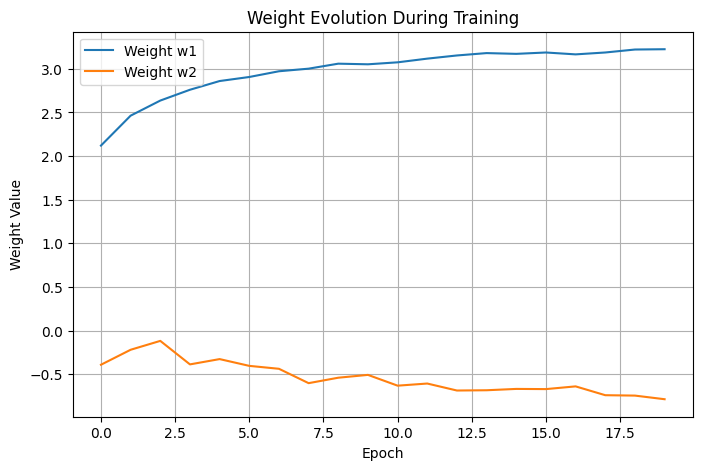

In [28]:
# Run training and weight tracking 

p2 = Perceptron(input_dim=2, learning_rate=0.1)

weight_history = train_with_tracking(p2, X_tensor, y_tensor, epochs=20)

plot_weight_evolution(weight_history)

## Task 5: Experimentation with Learning Rates
**Context:** Learning rate is a critical hyperparameter that affects how quickly and effectively a model learns. In production environments, finding the optimal learning rate can significantly impact model performance.

**Steps:**

1. Modify your training code to experiment with different learning rates
    - Create a list of learning rates to test (e.g., [0.001, 0.01, 0.1, 1.0])
    - Train separate models with each learning rate
    - Track and store training metrics for each

In [29]:
# Implement learning rate experiment

learning_rates = [0.001, 0.01, 0.1, 1.0]
epochs = 20

results = {}  # store accuracy curves
models = {}   # store trained models

def train_and_record(model, X, y, epochs):
    acc_history = []
    for epoch in range(epochs):
        indices = torch.randperm(len(X))
        for i in indices:
            model.update(X[i], y[i])
        acc = compute_accuracy(model, X, y)
        acc_history.append(acc)
    return acc_history


for lr in learning_rates:
    print(f"\nTraining model with learning rate = {lr}")
    model = Perceptron(input_dim=2, learning_rate=lr)
    acc_curve = train_and_record(model, X_tensor, y_tensor, epochs)
    results[lr] = acc_curve
    models[lr] = model


Training model with learning rate = 0.001

Training model with learning rate = 0.01

Training model with learning rate = 0.1

Training model with learning rate = 1.0


2. Visualize the impact of learning rates
    - Create a plot comparing accuracy over epochs for different learning rates
    - Plot decision boundaries for models trained with different rates

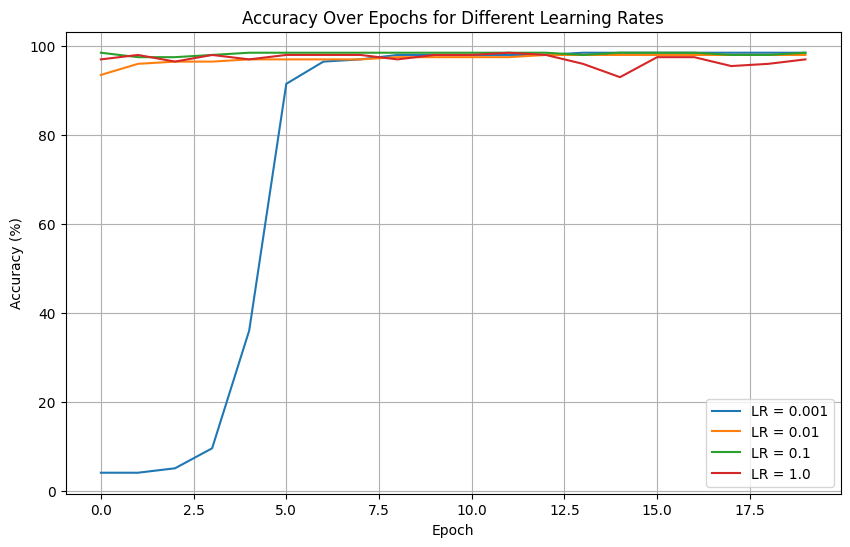

In [30]:
# Create visualization comparing learning rate effects

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(results[lr], label=f"LR = {lr}")

plt.title("Accuracy Over Epochs for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

3. Analyze and document your findings
    - Compare convergence speed and final accuracy
    - Identify the optimal learning rate for this dataset

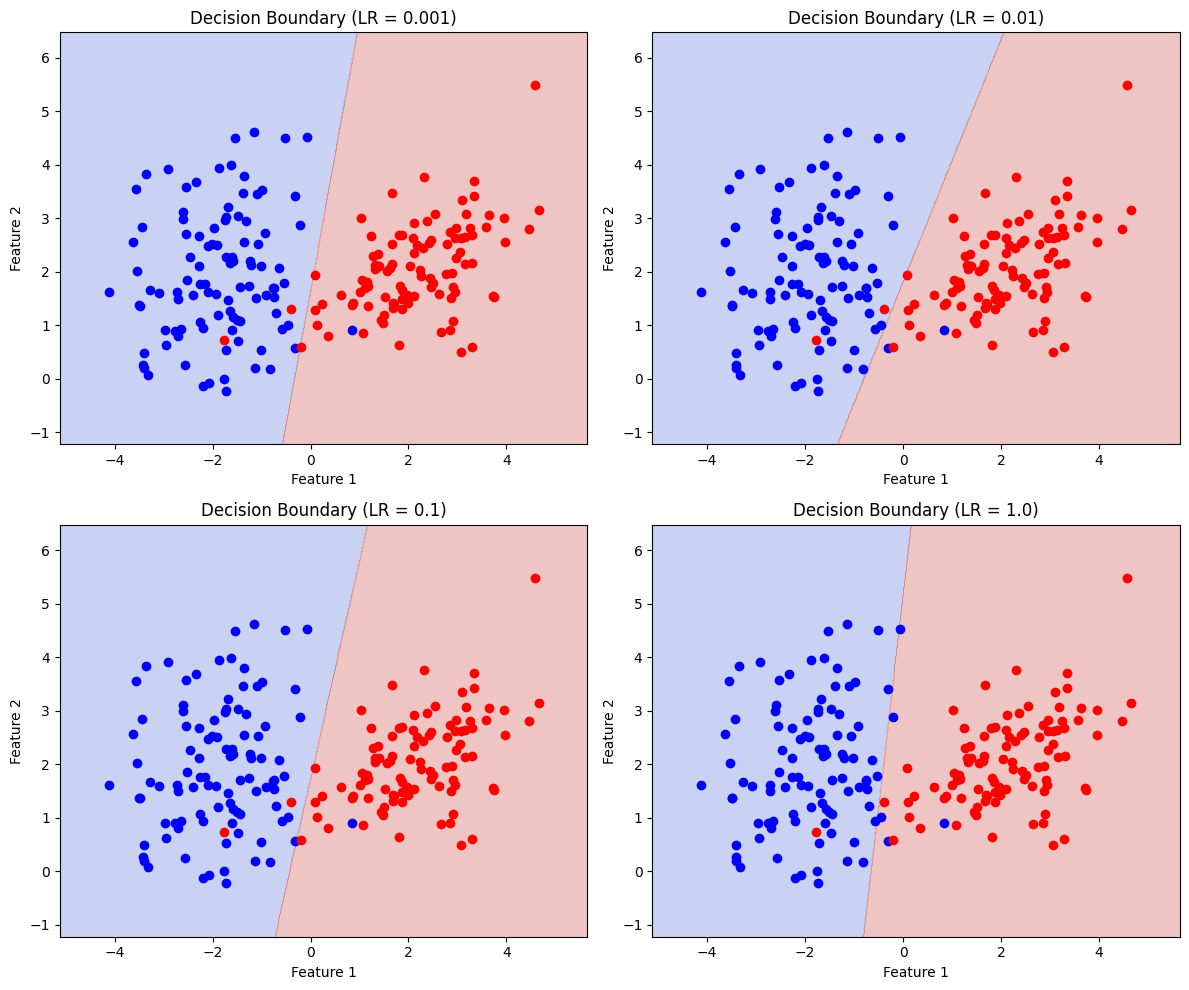

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, lr in zip(axes.flatten(), learning_rates):
    model = models[lr]

    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    preds = []
    for point in grid_tensor:
        pred = model.forward(point)
        preds.append(1 if pred >= 0.5 else 0)

    Z = np.array(preds).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='blue')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='red')

    ax.set_title(f"Decision Boundary (LR = {lr})")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [31]:
# Add code to print analysis of learning rate effects

print("\n=== Learning Rate Analysis ===")

for lr in learning_rates:
    final_acc = results[lr][-1]
    print(f"LR = {lr:>5} | Final Accuracy = {final_acc:.2f}%")

print("\nInterpretation:")
print("- Very small LR (0.001) learns slowly and may not converge in 20 epochs.")
print("- Moderate LR (0.01, 0.1) usually converges smoothly and reliably.")
print("- Very large LR (1.0) may overshoot, oscillate, or converge unstably.")


=== Learning Rate Analysis ===
LR = 0.001 | Final Accuracy = 98.50%
LR =  0.01 | Final Accuracy = 98.00%
LR =   0.1 | Final Accuracy = 98.50%
LR =   1.0 | Final Accuracy = 97.00%

Interpretation:
- Very small LR (0.001) learns slowly and may not converge in 20 epochs.
- Moderate LR (0.01, 0.1) usually converges smoothly and reliably.
- Very large LR (1.0) may overshoot, oscillate, or converge unstably.
